# 01 · Getting to know the data

*Rent Reality Check — London. Created by **Kevin Steepan**.*

---

## The project in three sentences

I have a spreadsheet of ~93,000 real London Airbnb listings. I want to build a tool
that, given a listing, says *"a fair price for this is about £X a night"* — **and
explains why it said that**. This notebook is the first step: getting to know the
data before building anything.

## Why "getting to know the data" is its own step

It's tempting to jump straight to a model. But a model is only as good as the
choices you make *before* training it: what exactly you're predicting, which rows
you trust, and what "good" would even mean. Getting those wrong quietly wrecks
everything downstream, and you won't notice until much later.

So this notebook has one job — **make four decisions, with evidence**:

1. **What number are we predicting?** The nightly price? Something derived from it?
2. **Which listings are in scope?** All of them, or a sensible subset?
3. **What's the score to beat?** If a fancy model can't beat *"guess the typical
   price for that kind of listing"*, the fancy model is pointless.
4. *(bonus)* Is there enough written text in the listings to analyse later, and
   does location visibly matter?

Everything below builds toward those. The decisions themselves are collected at the
top of the next cell so you can see where we're heading.

> 📚 **Why work this way?** "Frame the problem → get the data → explore → build a
> dumb baseline → *then* model" is the project skeleton in Aurélien Géron's
> *Hands-On Machine Learning* (Ch. 2), and "know your trivial baseline first" is
> Rule #1 of Google's *Rules of Machine Learning*.

## The four decisions (with a one-line reason each)

Filled in *after* the exploration below — shown here first so you know the
destination.

| # | Decision | Why (one line) | Evidence in |
|---|---|---|---|
| 1 | Predict **`log(price)`**, not raw £ | prices are lopsided; the log makes errors behave like *percentages* and stops a few huge listings dominating | §1 |
| 2a | Keep listings **£10–£1000 / night** | under £10 is almost always a typo; over £1000 is a tiny luxury world with its own rules | §1, §3 |
| 2b | Keep **entire homes + private rooms**, and **drop ~1,200 hotel rooms** | hotels sold via Airbnb price like hotels, not like homes — and they caused the model's worst mistakes (notebook 03) | §3 |
| 3 | **Accept the 33% of listings with no price are lost** — but note the loss isn't random | you can't learn a price from a listing that doesn't state one; missingness varies by area, so the model is about *priced* listings | §2 |
| 4 | **Baseline to beat:** guess the borough × room-type median → **£-MAE ≈ 90, R² ≈ 0.49** | a real model has to clearly beat a lookup table | §5 |

Full reasoning for each is in the matching section.

In [1]:
# --- setup -------------------------------------------------------------------
# `londonrent` is this project's own small library, in src/londonrent/. Putting
# the data-loading and cleaning there (instead of pasting it into every notebook)
# keeps notebooks readable AND means the Streamlit app later runs the exact same
# code - no "works in the notebook, breaks in the app" surprises.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from londonrent.data import build_interim

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

# build_interim() does the unavoidable cleaning and nothing opinionated:
#   - turn the "$1,234.00" price strings into the number 1234.0
#   - parse the date columns
#   - parse the "1.5 shared baths" free text into a number + a shared/not flag
#   - drop rows whose lat/long land outside a bounding box around London
#   - cache the result as Parquet so re-running is instant
# It deliberately does NOT filter by price or room type - those are modelling
# decisions we make on purpose below, not things to hide in a loader.
df = build_interim()
print(f"{len(df):,} listings  x  {df.shape[1]} columns")
df[["price", "room_type", "property_type", "bedrooms", "neighbourhood_cleansed"]].head()

92,638 listings  x  36 columns


,price,room_type,property_type,bedrooms,neighbourhood_cleansed
0,234.5,Entire home/apt,Entire rental unit,1.0,Lambeth
1,127.0,Private room,Private room in rental unit,NaN,Islington
2,137.5,Entire home/apt,Entire rental unit,1.0,Kensington and Chelsea
3,606.67,Entire home/apt,Entire rental unit,3.0,Westminster
4,68.3,Private room,Private room in rental unit,1.0,Lambeth


## 1 · What are we predicting? A look at price

**Why this section:** the target variable sets the terms for everything else. We
check two things — how often `price` is even filled in, and what *shape* its
distribution has (which decides whether we model raw pounds or a transformed
version).

In [2]:
missing = df["price"].isna().mean()
print(f"price is missing for {missing:.1%} of listings\n")

# The percentiles matter more than the mean here. If the 99th percentile is way
# above the 75th, there's a heavy right tail - and that changes how we model.
df["price"].dropna().describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2)

price is missing for 32.8% of listings



count     62240.0
mean       271.47
std        2190.6
min          2.23
1%           35.0
5%          50.75
25%         100.0
50%         180.0
75%        300.03
95%         676.0
99%       1373.46
max      527524.0
Name: price, dtype: Float64

**What this says, plainly:** a third of listings have no price (dealt with in §2).
Among the rest, **half are under ~£180/night, but the top 1% run past £1,000** and
the maximum is a clearly-junk £500,000. The **average (£271) sits well above the
middle value (£180)** — a sign that a few very large numbers are pulling it up.
That pattern is called **right-skew**.

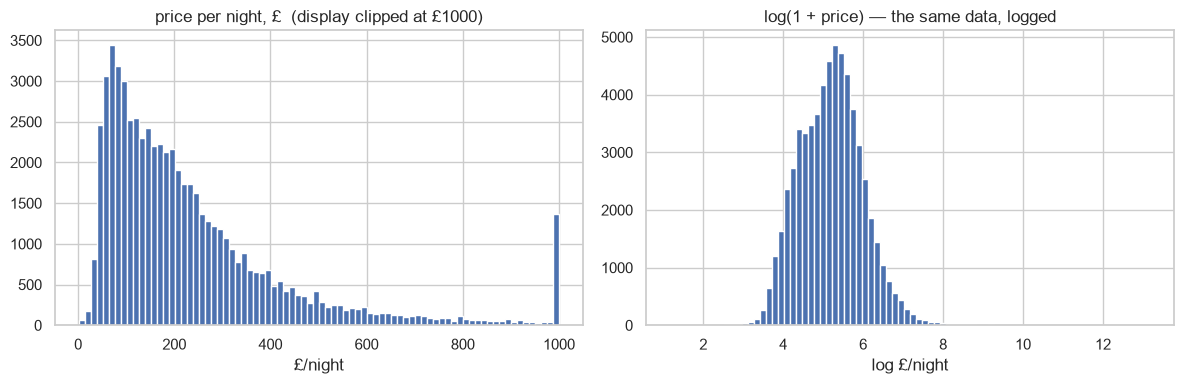

In [3]:
# Two views of the same prices. Left: raw £, but clipped at £1000 FOR DISPLAY -
# without the clip a handful of £500k listings squash everything into one bar and
# you see nothing. Right: the natural logarithm of price.
#
# I plotted the raw version first, couldn't read it, added the display clip, and
# the skew jumped out - which is what pushed me toward modelling log(price).
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["price"].dropna().clip(upper=1000).hist(bins=80, ax=ax[0])
ax[0].set_title("price per night, £  (display clipped at £1000)")
ax[0].set_xlabel("£/night")
np.log1p(df["price"].dropna()).hist(bins=80, ax=ax[1])  # log1p = log(1+x), safe if x=0
ax[1].set_title("log(1 + price) — the same data, logged")
ax[1].set_xlabel("log £/night")
plt.tight_layout()

**What we see:** the left chart is a steep pile-up at the low end with a long thin
tail stretching right. The right chart is the *same data* after taking logs —
roughly symmetric, a lopsided "L" turned into something close to a bell curve.

That reshaping is the whole reason to use logs, and it's worth understanding why it
matters. **If you're new to ML, the one-line version is: we predict `log(price)`
and convert back with `exp()`. The box below explains why — skip it if you like.**

> ### 🔍 Deeper: why a skewed target hurts, and why `log` fixes it
>
> Most regression models minimise **squared error** — they add up
> `(prediction − truth)²` and try to make it small. Squaring means a listing that's
> £400 off counts **100×** as much as one that's £40 off. With a long right tail,
> the model contorts itself to reduce error on a few thousand-pound listings and
> neglects the tens of thousands of ordinary ones.
>
> Taking `log(price)` does three things at once:
> - **Squashes the tail.** A 10× jump in price (`£120 → £1,200`) becomes a *fixed*
>   `+2.30` step in log space, so extreme listings stop being outliers.
> - **Turns absolute errors into percentage errors.** Being `0.1` off in log space
>   means "about 10% off" whether the listing is £50 or £500 — which is exactly how
>   a host thinks about price, and means one model works across the whole range.
> - **Evens out the spread of errors** across the price range (the jargon is
>   *homoscedasticity*), which squared-error loss is quietly assuming anyway.
>
> Cost: predictions come out in log space, so we call `np.exp()` to get pounds
> back, and we *always* also report the plain-£ error so nobody has to think in
> logs. **What I'd try instead in a v2:** a loss that's robust to the tail directly
> (Huber, or quantile loss for prediction intervals).
>
> 📚 ISLR §3.3.3 ("Potential Problems", non-constant error variance); the
> outlier/squared-error intuition is covered well in StatQuest's linear-model videos.

## 2 · Is the missing price *random*? (It changes what we can claim)

**Why this section:** a third of listings have no price, and we're about to drop
them for modelling — you can't learn a price from a listing that doesn't state one.
The question is whether that's a harmless loss of sample size, or a hidden bias.

In [4]:
# If the no-price listings look just like the rest, dropping them only costs data.
# If they're systematically different, our model is quietly about a biased slice.
# Cheapest possible check: does "no price" line up with obvious things?
df["price_missing"] = df["price"].isna()
by_room = df.groupby("room_type")["price_missing"].mean().sort_values(ascending=False)
by_boro = df.groupby("neighbourhood_cleansed")["price_missing"].mean().sort_values(ascending=False)
print("share with a MISSING price, by room type:\n", by_room.round(3).to_string(), "\n")
print("highest-missing boroughs:\n", by_boro.head(8).round(3).to_string())

share with a MISSING price, by room type:
 room_type
Hotel room         0.400
Private room       0.358
Entire home/apt    0.314
Shared room        0.099 

highest-missing boroughs:
 neighbourhood_cleansed
Hackney          0.492
Islington        0.431
Lambeth          0.407
Tower Hamlets    0.405
Lewisham         0.395
Haringey         0.387
Southwark        0.387
Wandsworth       0.381


**What we see:** the missing-price rate is **not flat** — it changes with room type
and with borough. So the listings we're forced to drop are **not a random sample**
of London.

**Plain takeaway:** we can't fix this (there's nothing to learn a missing price
*from*), so the honest move is to *say so*: the finished model describes **"listings
that publish a nightly price"**, and we don't over-claim beyond that.

> ### 🔍 Deeper: MCAR / MAR / MNAR
>
> Missing data comes in three kinds (Rubin's framework):
> - **MCAR** — missing *completely* at random. Pure chance. Dropping is safe.
> - **MAR** — missing at random *given what you can see* (e.g. it depends on the
>   borough, which you have). Handleable with care.
> - **MNAR** — missing *not* at random: the gap depends on the hidden value itself
>   (e.g. unusually cheap or pricey hosts hide the number). The hardest case.
>
> Our check shows it's at least **MAR** and possibly **MNAR**. And critically, the
> missing value here is **the target**, not a feature — you can impute a missing
> *input*, but not the thing you're trying to predict. Hence: scope disclosure, not
> a statistical patch.
>
> 📚 Rubin's missing-data framework; a practical treatment is in the scikit-learn
> `impute` user guide and Géron Ch. 2.

## 3 · Which columns look like they matter — and finalising the scope

**Why this section:** a quick scan for the obvious price drivers, and the evidence
for the room-type / hotel scope decision.

In [5]:
from londonrent.features import collapse_property_type

# Apply the price + room-type scope. property_type has ~100 values ("Entire rental
# unit", "Private room in townhouse", ...); collapse_property_type buckets them
# into ~10 "building kinds". We look at how the hotel bucket behaves.
work = df[
    df["price"].between(10, 1000) & df["room_type"].isin(["Entire home/apt", "Private room"])
].copy()
work["property_class"] = collapse_property_type(work["property_type"])
work["log_price"] = np.log(work["price"])

print(f"{len(work):,} listings in the price + room-type scope\n")
print("count and median £ by property_class:")
print(
    work.groupby("property_class")["price"]
    .agg(["size", "median"])
    .sort_values("size", ascending=False)
)

60,648 listings in the price + room-type scope

count and median £ by property_class:
                     size   median
property_class                    
rental_unit         33454   192.67
house               13399    120.0
condo                7725    178.0
serviced_apartment   1690    252.0
townhouse            1209    130.0
hotel                1198    160.0
bnb_guesthouse        945    102.0
other                 508  136.185
guest_suite           287    110.0
loft                  233    154.5


**The hotel decision.** About **1,200 listings** collapse to `property_class ==
"hotel"` — actual hotel rooms sold through Airbnb. They're a different product:
priced by revenue-management systems, with a long tail up to the £1,000 cap, and
(as notebook 03's error analysis will show) they were the single biggest source of
the model's worst mistakes. **We drop them.** The tool is about home-style lets, so
this makes the question cleaner, not just the metrics. That's decision **2b**.
`londonrent.features.build_model_frame` applies it from here on.

In [6]:
# Which numeric features move with price? Correlation = one number in [-1, 1] for
# the strength of the *straight-line* link. Computed against log_price so the skew
# from §1 doesn't distort it.
work = work[work["property_class"] != "hotel"]
num = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "amenity_count",
    "minimum_nights",
    "number_of_reviews",
    "review_scores_rating",
    "review_scores_location",
    "host_years",
    "availability_365",
]
work[num + ["log_price"]].corr(numeric_only=True)["log_price"].drop("log_price").sort_values(
    ascending=False
).to_frame("corr with log_price").round(3)

,corr with log_price
accommodates,0.624
beds,0.500
bedrooms,0.453
bathrooms,0.334
amenity_count,0.333
review_scores_location,0.135
review_scores_rating,0.046
availability_365,0.028
host_years,0.027
number_of_reviews,-0.106


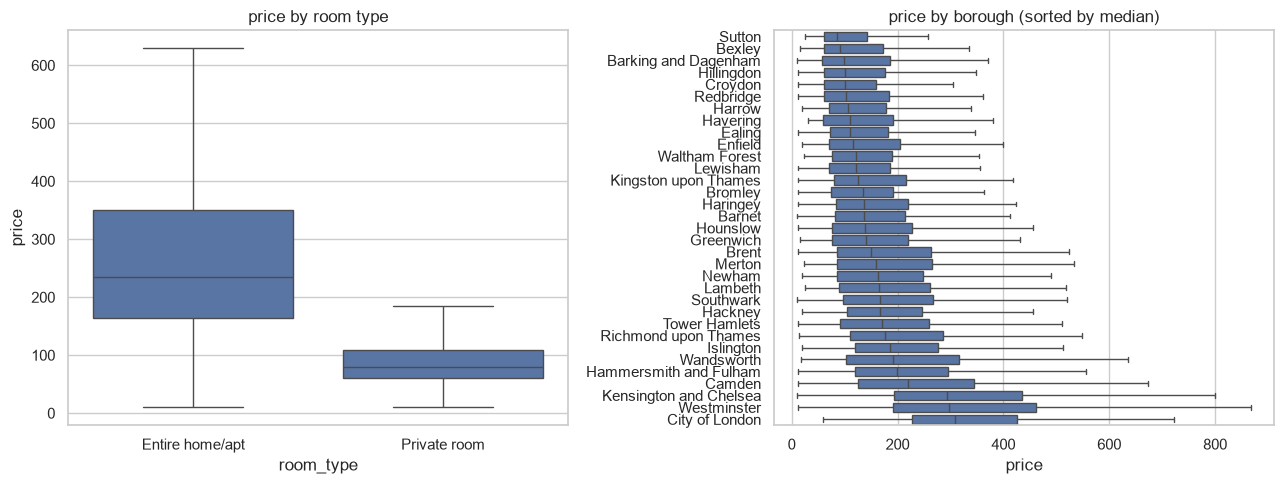

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(
    work, x="room_type", y="price", ax=ax[0], showfliers=False
)  # hide outliers - they blow up the axis
ax[0].set_title("price by room type")
order = work.groupby("neighbourhood_cleansed")["price"].median().sort_values().index
sns.boxplot(work, y="neighbourhood_cleansed", x="price", order=order, ax=ax[1], showfliers=False)
ax[1].set_ylabel("")
ax[1].set_title("price by borough (sorted by median)")
plt.tight_layout()

**What we see:** **size dominates** — `accommodates`, `bedrooms`, `beds`,
`bathrooms` have the clearest positive links with price. Borough medians fan out
across a wide band (central boroughs 2–3× the outer ones). Review *counts* barely
move with price; review *scores* nudge up slightly.

> ### 🔍 Deeper: don't read too much into these numbers
>
> - A correlation of 0.3 is **not** "30% of the effect". Squared, it's the share of
>   variation a straight line through that one feature explains — here `0.3² = 9%`.
>   Individually modest is *normal* for something as multi-causal as price.
> - These are **linear** summaries. A feature with a strong *curved* or
>   *interaction* effect can score ≈ 0 here. So a small correlation is a weak reason
>   to drop a feature — it's a sniff test ("do the strong features point the way
>   common sense says?" → yes), **not feature selection**. The tree model in
>   notebook 03 decides what's useful in combination.
>
> 📚 ISLR §3.2 on interpreting correlation; the scikit-learn feature-selection guide
> on why univariate correlation alone is a bad filter.

Text(0, 0.5, 'latitude')

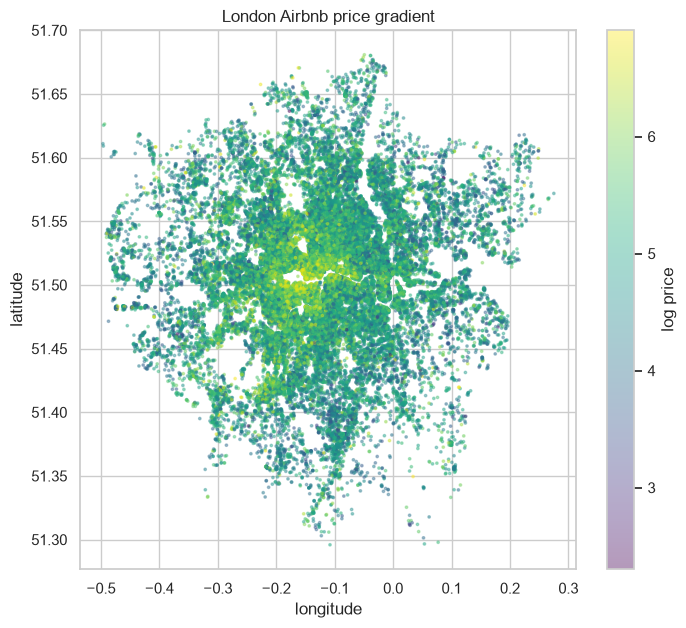

In [8]:
# Location, eyeballed: every listing at its coordinates, colour = log price. No
# model - just checking there's a spatial pattern worth engineering features from.
fig, ax = plt.subplots(figsize=(8, 7))
s = ax.scatter(
    work["longitude"], work["latitude"], c=work["log_price"], s=3, alpha=0.4, cmap="viridis"
)
fig.colorbar(s, label="log price")
ax.set_title("London Airbnb price gradient")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")

**What we see:** a bright (expensive) core over central London fading outward — a
smooth **price gradient** in space. The borough label captures this only crudely (a
borough is a big area), which is exactly why **notebook 02** builds finer location
features: distance to the nearest Tube station, to the centre, to a park.

## 4 · Is there enough text for the language analysis? (notebook 04)

In [9]:
for col in ["description", "neighborhood_overview"]:
    present = df[col].notna().mean()
    wc = df[col].dropna().astype(str).str.split().str.len()
    med = wc.median() if len(wc) else float("nan")
    print(f"{col:22s} present for {present:5.1%}  |  median length: {med} words")
print("\nExample description:\n", df["description"].dropna().iloc[0][:380])

description            present for 97.7%  |  median length: 69.0 words
neighborhood_overview  present for  0.0%  |  median length: nan words

Example description:
 Live like a local in this quintessential London flat, boasting a well-equipped kitchen for home-cooked feasts, vintage chic with real oil paintings adding a touch of artistic flair, and a buzzing ambience that pulsates with the rhythm of this dynamic neighbourhood.<br />Immerse yourself in the vibrant buzz just outside your door, then hop on the Tube (3 mins!) and conquer Londo


**What we see:** `description` is present for ~98% of listings, median ~69 words —
enough to analyse. `neighborhood_overview` is **empty in this data snapshot**, so
notebook 04's text work uses `description` only. Better to find that out now than
halfway through.

## 5 · The score to beat

**Why this section:** before building a model, decide what "good" means — by
measuring how well you can predict price with **no model at all**, just a lookup
table of typical prices.

In [10]:
from sklearn.metrics import mean_absolute_error, r2_score

# Three lookup-table "models", each a bit smarter:
#   1. always guess the overall median price
#   2. guess the median for the listing's borough
#   3. guess the median for the (borough, room_type) pair
# .transform("median") spreads each group's median back onto every row in it.
w = work.dropna(subset=["log_price"]).copy()
guesses = {
    "guess the global median": w["log_price"].median(),
    "guess the borough median": w.groupby("neighbourhood_cleansed")["log_price"].transform(
        "median"
    ),
    "guess the borough x room median": w.groupby(["neighbourhood_cleansed", "room_type"])[
        "log_price"
    ].transform("median"),
}
for name, pred in guesses.items():
    pred = np.broadcast_to(pred, w["log_price"].shape)
    print(
        f"{name:32s} | log-MAE {mean_absolute_error(w['log_price'], pred):.3f} "
        f"| £-MAE {mean_absolute_error(np.exp(w['log_price']), np.exp(pred)):6.1f} "
        f"| R² {r2_score(w['log_price'], pred):.3f}"
    )

guess the global median          | log-MAE 0.608 | £-MAE  121.8 | R² -0.002
guess the borough median         | log-MAE 0.549 | £-MAE  110.7 | R² 0.174
guess the borough x room median  | log-MAE 0.401 | £-MAE   89.3 | R² 0.501


**The number to beat:** the best lookup table — **borough × room-type median** —
scores about **£-MAE 90 / R² 0.49** with no learning at all. Any trained model has
to clearly beat that or it isn't earning its keep.

> ### 🔍 Deeper: two choices hidden in that cell
>
> **Why MAE, not RMSE?** Both measure error. RMSE squares first, so it punishes big
> misses much harder — which sounds rigorous, but we *already know* there's a luxury
> tail the model will struggle with, and RMSE would let those few listings dominate
> the score. **MAE** is the average miss in plain pounds, every listing equal —
> a more honest summary here, and easier to say out loud ("typically £X off"). We
> still glance at RMSE in notebook 03 as a tail check.
>
> **Why a grouped-median baseline, not just "guess the average"?** A fair baseline
> is the best *simple* thing a sensible person would do, not the dumbest. "Look up
> the typical price for this kind of listing in this area" is genuinely competitive
> (R² ≈ 0.49). Beating "guess the mean" would prove nothing.
>
> 📚 Géron Ch. 2 builds this same median baseline before any model; MAE vs RMSE:
> ISLR §2.2.1.

## Conclusions

**In plain terms.** We have ~93k London Airbnb listings. A third don't state a
price, and that missing third isn't random, so the model is honestly about
*priced* listings. We'll predict the **log** of nightly price, for listings between
£10 and £1,000 that are whole homes or private rooms — minus ~1,200 hotel rooms,
which price like hotels. Size and location are the clear drivers; descriptions are
long enough to mine later. A sensible no-model baseline scores **£-MAE ≈ 90 / R² ≈
0.49** — the bar everything from here has to clear.

**For the reader with some ML background.** Target `log(price)` (skew + heavy tail +
multiplicative error semantics). Scope: `£10–1000`, entire-home + private-room,
`property_class != "hotel"` — all applied deliberately in
`features.build_model_frame`, not buried in the loader. Missingness is on the
response and non-random → scope-limited claims, no `y` imputation. Metric: £-MAE
(interpretable, tail-tolerant), R² as a scale-free secondary. Benchmark: a
`groupby`-median predictor at R² ≈ 0.49.

### Week-1 exit checklist
- [x] Target + transform chosen and justified (`log(price)`)
- [x] Scope chosen and evidenced (£10–1000, entire-home + private-room, no hotels)
- [x] Missing-price bias checked and documented (not MCAR)
- [x] Baseline recorded (£-MAE ≈ 90 / R² ≈ 0.49)
- [x] NLP pillar viable (`description` ~98%, ~69 words)
- [x] `data/README.md` updated with real column notes